# Notebook 01 — Eksplorasi dan Analisis Data
## Dataset: Telco Customer Churn

Notebook ini mengeksplorasi data 7.043 pelanggan dari sebuah perusahaan telekomunikasi. Setiap visualisasi dirancang untuk menjawab satu pertanyaan bisnis yang konkret — bukan sekadar statistik deskriptif, tapi insight yang bisa langsung ditindaklanjuti.

---

## 1. Memuat Data dan Library

Dataset IBM Telco Customer Churn tersedia publik di Kaggle. Berisi 7.043 pelanggan dengan 21 variabel termasuk demografi, layanan berlangganan, informasi tagihan, dan status churn sebagai variabel target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Styling konsisten dan bersih
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlepad": 14,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE  = "#3B82F6"
RED   = "#EF4444"
GREEN = "#10B981"
GOLD  = "#F59E0B"
DARK  = "#1E3A5F"
GRAY  = "#94A3B8"
PALETTE = {"No": BLUE, "Yes": RED}

# Load data
df = pd.read_csv("../WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["MonthlyCharges"], inplace=True)
df["Churn_Num"] = (df["Churn"] == "Yes").astype(int)

print(f"Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Churn  : {df['Churn_Num'].sum():,} pelanggan ({df['Churn_Num'].mean():.1%})")
print(f"Non-Churn: {(df['Churn']=='No').sum():,} pelanggan")
df.head(3)


Dataset: 7,043 baris x 22 kolom
Churn  : 1,869 pelanggan (26.5%)
Non-Churn: 5,174 pelanggan


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


## 2. Distribusi Churn: Seberapa Besar Masalah Ini?

Langkah pertama adalah memahami skala masalah. Proporsi churn menentukan seberapa serius dampak finansialnya dan juga mempengaruhi pendekatan modeling — data yang tidak seimbang memerlukan teknik khusus agar model tidak memihak kelas mayoritas.

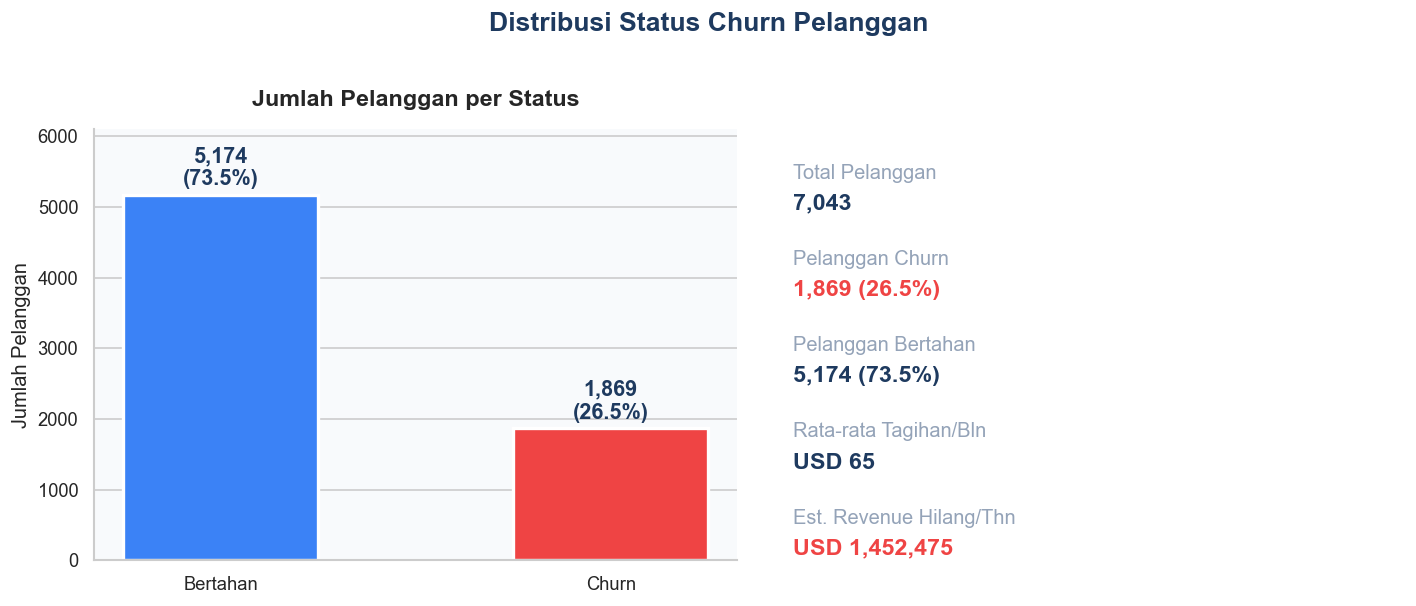

In [2]:
counts = df["Churn"].value_counts()
pct    = df["Churn"].value_counts(normalize=True)
rev_loss = counts["Yes"] * df["MonthlyCharges"].mean() * 12

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kiri: Bar chart sederhana dan jelas
bars = axes[0].bar(
    ["Bertahan", "Churn"],
    [counts["No"], counts["Yes"]],
    color=[BLUE, RED], width=0.5, edgecolor="white", linewidth=2
)
for bar, val, pv in zip(bars, [counts["No"], counts["Yes"]], [pct["No"], pct["Yes"]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f"{val:,}\n({pv:.1%})", ha="center", va="bottom",
                 fontsize=13, fontweight="bold", color=DARK)

axes[0].set_title("Jumlah Pelanggan per Status")
axes[0].set_ylabel("Jumlah Pelanggan")
axes[0].set_ylim(0, max(counts)*1.18)
axes[0].grid(axis="x", alpha=0)

# Kanan: Penjelasan bisnis
axes[1].axis("off")
info = [
    ("Total Pelanggan",        f"{len(df):,}"),
    ("Pelanggan Churn",        f"{counts['Yes']:,} ({pct['Yes']:.1%})"),
    ("Pelanggan Bertahan",     f"{counts['No']:,} ({pct['No']:.1%})"),
    ("Rata-rata Tagihan/Bln",  f"USD {df['MonthlyCharges'].mean():.0f}"),
    ("Est. Revenue Hilang/Thn",f"USD {rev_loss:,.0f}"),
]
t = 0.92
for label, value in info:
    axes[1].text(0.05, t, label, transform=axes[1].transAxes,
                 fontsize=12, color=GRAY, va="top")
    color = RED if "Churn" in label or "Hilang" in label else DARK
    axes[1].text(0.05, t-0.07, value, transform=axes[1].transAxes,
                 fontsize=14, fontweight="bold", color=color, va="top")
    t -= 0.20

plt.suptitle("Distribusi Status Churn Pelanggan", fontsize=16, fontweight="bold", color=DARK, y=1.01)
plt.tight_layout()
plt.savefig("../reports/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Kapan Pelanggan Paling Rentan Pergi?

Lama berlangganan (tenure) adalah prediktor churn yang paling kuat. Distribusinya sangat berbeda antara churner dan non-churner. Memahami pola ini menentukan kapan program intervensi harus dimulai dan kepada siapa diprioritaskan.

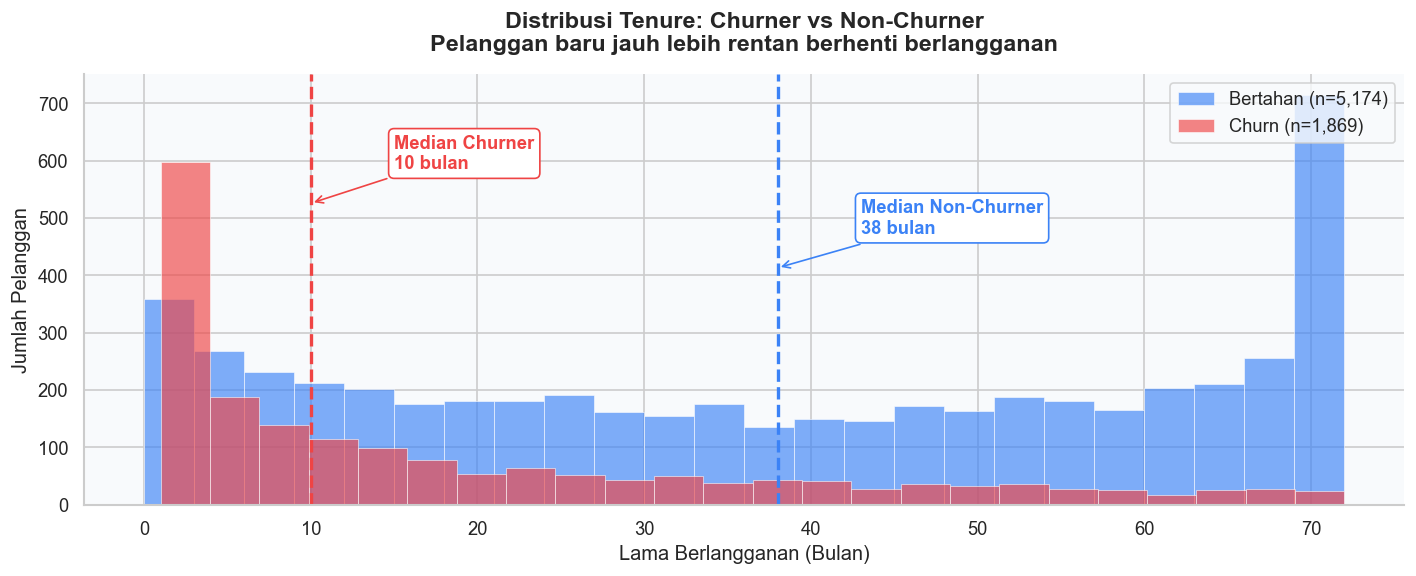

Perbedaan median tenure: 28 bulan
12 bulan pertama adalah jendela kritis yang harus menjadi fokus utama program retensi.


In [3]:
med_churn = df[df["Churn"]=="Yes"]["tenure"].median()
med_stay  = df[df["Churn"]=="No"]["tenure"].median()

fig, ax = plt.subplots(figsize=(12, 5))

for label, color, name in [("No", BLUE, "Bertahan"), ("Yes", RED, "Churn")]:
    subset = df[df["Churn"]==label]["tenure"]
    ax.hist(subset, bins=24, alpha=0.65, color=color, label=f"{name} (n={len(subset):,})",
            edgecolor="white", linewidth=0.5)

ax.axvline(med_churn, color=RED, linestyle="--", linewidth=2)
ax.axvline(med_stay,  color=BLUE, linestyle="--", linewidth=2)

ax.annotate(f"Median Churner\n{med_churn:.0f} bulan",
            xy=(med_churn, ax.get_ylim()[1]*0.7),
            xytext=(med_churn + 5, ax.get_ylim()[1]*0.78),
            arrowprops=dict(arrowstyle="->", color=RED),
            color=RED, fontsize=11, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=RED))

ax.annotate(f"Median Non-Churner\n{med_stay:.0f} bulan",
            xy=(med_stay, ax.get_ylim()[1]*0.55),
            xytext=(med_stay + 5, ax.get_ylim()[1]*0.63),
            arrowprops=dict(arrowstyle="->", color=BLUE),
            color=BLUE, fontsize=11, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=BLUE))

ax.set_title("Distribusi Tenure: Churner vs Non-Churner\n"
             "Pelanggan baru jauh lebih rentan berhenti berlangganan")
ax.set_xlabel("Lama Berlangganan (Bulan)")
ax.set_ylabel("Jumlah Pelanggan")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../reports/tenure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Perbedaan median tenure: {med_stay - med_churn:.0f} bulan")
print(f"12 bulan pertama adalah jendela kritis yang harus menjadi fokus utama program retensi.")


## 4. Tipe Kontrak: Lever Bisnis Paling Berdampak

Dari seluruh variabel kategorikal yang diuji, tipe kontrak menunjukkan perbedaan churn rate paling dramatis. Ini juga variabel yang paling bisa diintervensi langsung oleh tim bisnis tanpa perlu mengubah infrastruktur layanan.

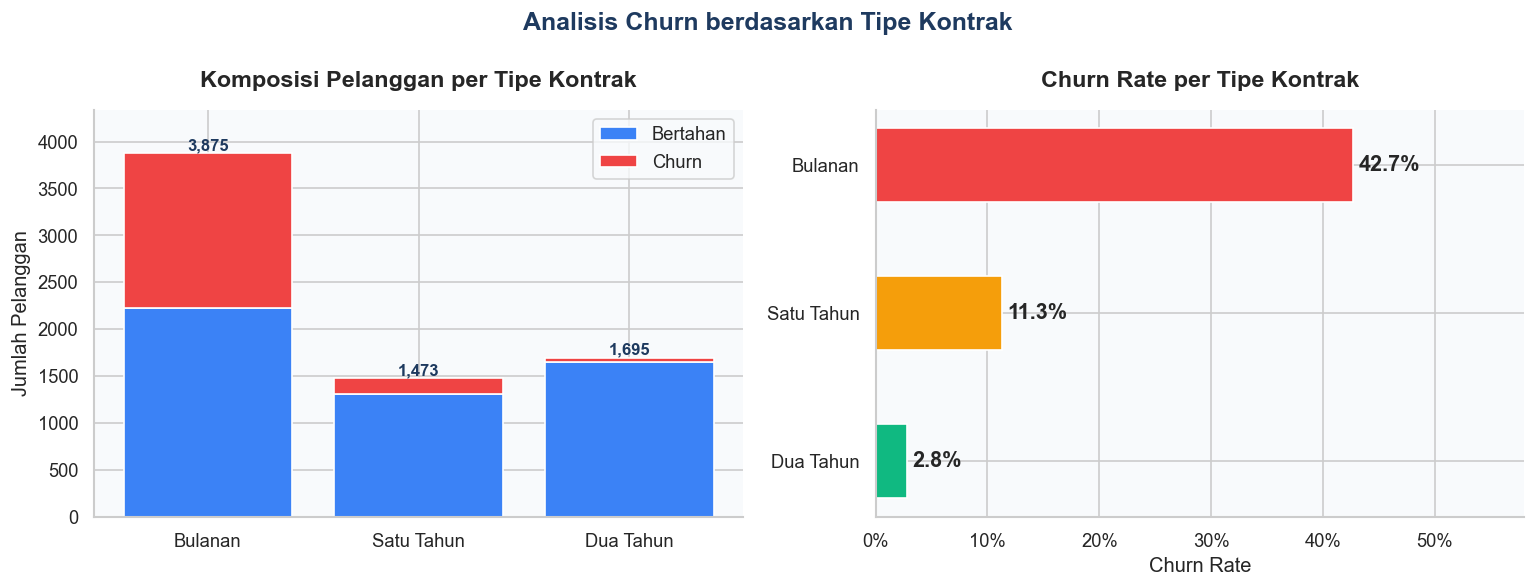

  Bulanan     : 42.7% churn  (1655/3875)
  Satu Tahun  : 11.3% churn  (166/1473)
  Dua Tahun   : 2.8% churn  (48/1695)


In [4]:
label_map = {"Month-to-month": "Bulanan", "One year": "Satu Tahun", "Two year": "Dua Tahun"}
df["Kontrak"] = df["Contract"].map(label_map)

contract_rate = (
    df.groupby("Kontrak")["Churn_Num"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "churn_rate", "count": "total", "sum": "churn"})
    .reset_index()
    .sort_values("churn_rate", ascending=False)
)
contract_rate["retained"] = contract_rate["total"] - contract_rate["churn"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Kiri: stacked bar jumlah
kontrak_labels = contract_rate["Kontrak"].tolist()
b1 = axes[0].bar(kontrak_labels, contract_rate["retained"], color=BLUE,
                 label="Bertahan", edgecolor="white")
b2 = axes[0].bar(kontrak_labels, contract_rate["churn"], bottom=contract_rate["retained"],
                 color=RED, label="Churn", edgecolor="white")

for bar, total in zip(b2, contract_rate["total"]):
    y = bar.get_y() + bar.get_height() + 30
    axes[0].text(bar.get_x() + bar.get_width()/2, total + 40,
                 f"{total:,}", ha="center", fontsize=10, color=DARK, fontweight="bold")

axes[0].set_title("Komposisi Pelanggan per Tipe Kontrak")
axes[0].set_ylabel("Jumlah Pelanggan")
axes[0].legend()
axes[0].set_ylim(0, contract_rate["total"].max() * 1.12)

# Kanan: churn rate bar dengan warna
bar_colors = [RED if r > 0.30 else GOLD if r > 0.10 else GREEN
              for r in contract_rate["churn_rate"]]
bars = axes[1].barh(kontrak_labels, contract_rate["churn_rate"],
                    color=bar_colors, height=0.5, edgecolor="white")

for bar, rate in zip(bars, contract_rate["churn_rate"]):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f"{rate:.1%}", va="center", fontsize=13, fontweight="bold")

axes[1].set_title("Churn Rate per Tipe Kontrak")
axes[1].set_xlabel("Churn Rate")
axes[1].set_xlim(0, 0.58)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].invert_yaxis()

plt.suptitle("Analisis Churn berdasarkan Tipe Kontrak", fontsize=15, fontweight="bold", color=DARK)
plt.tight_layout()
plt.savefig("../reports/contract_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

for _, row in contract_rate.iterrows():
    print(f"  {row['Kontrak']:12s}: {row['churn_rate']:.1%} churn  ({row['churn']:.0f}/{row['total']:.0f})")


## 5. Metode Pembayaran: Otomatis vs Manual

Cara pelanggan membayar tagihan berkorelasi kuat dengan loyalitas. Pembayaran otomatis menciptakan hambatan positif yang membuat berhenti berlangganan memerlukan usaha ekstra, sementara pembayaran manual memberi kebebasan penuh untuk kapan saja berhenti.

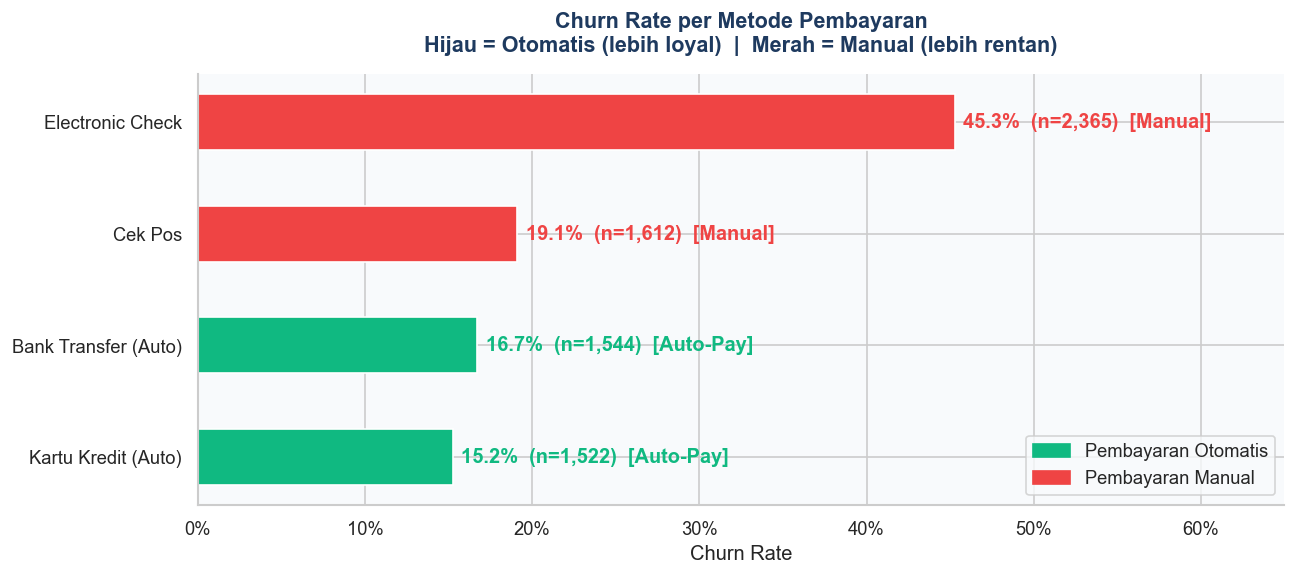

In [5]:
pay_rate = (
    df.groupby("PaymentMethod")["Churn_Num"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "total"})
    .reset_index()
    .sort_values("churn_rate")
)

# Singkat nama untuk label
short_name = {
    "Bank transfer (automatic)": "Bank Transfer (Auto)",
    "Credit card (automatic)":   "Kartu Kredit (Auto)",
    "Electronic check":          "Electronic Check",
    "Mailed check":              "Cek Pos"
}
pay_rate["Label"] = pay_rate["PaymentMethod"].map(short_name)
pay_rate["IsAuto"] = pay_rate["PaymentMethod"].str.contains("automatic")

bar_colors = [GREEN if auto else RED for auto in pay_rate["IsAuto"]]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(pay_rate["Label"], pay_rate["churn_rate"],
               color=bar_colors, height=0.5, edgecolor="white")

for bar, rate, total, auto in zip(bars, pay_rate["churn_rate"],
                                   pay_rate["total"], pay_rate["IsAuto"]):
    keterangan = "Auto-Pay" if auto else "Manual"
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{rate:.1%}  (n={total:,})  [{keterangan}]",
            va="center", fontsize=12, fontweight="bold",
            color=GREEN if auto else RED)

ax.set_xlim(0, 0.65)
ax.set_xlabel("Churn Rate")
ax.set_title("Churn Rate per Metode Pembayaran\n"
             "Hijau = Otomatis (lebih loyal)  |  Merah = Manual (lebih rentan)",
             fontsize=13, fontweight="bold", color=DARK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Legend manual
patch_auto   = mpatches.Patch(color=GREEN, label="Pembayaran Otomatis")
patch_manual = mpatches.Patch(color=RED,   label="Pembayaran Manual")
ax.legend(handles=[patch_auto, patch_manual], loc="lower right")

plt.tight_layout()
plt.savefig("../reports/payment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Anomali Fiber Optic: Mengapa Layanan Premium Memiliki Churn Terbanyak?

Temuan ini mengejutkan. Pelanggan Fiber Optic — yang membayar paling mahal — justru memiliki churn rate tertinggi. Hipotesis yang muncul: ada gap antara harga yang dibayar dan pengalaman atau kualitas layanan yang diterima pelanggan.

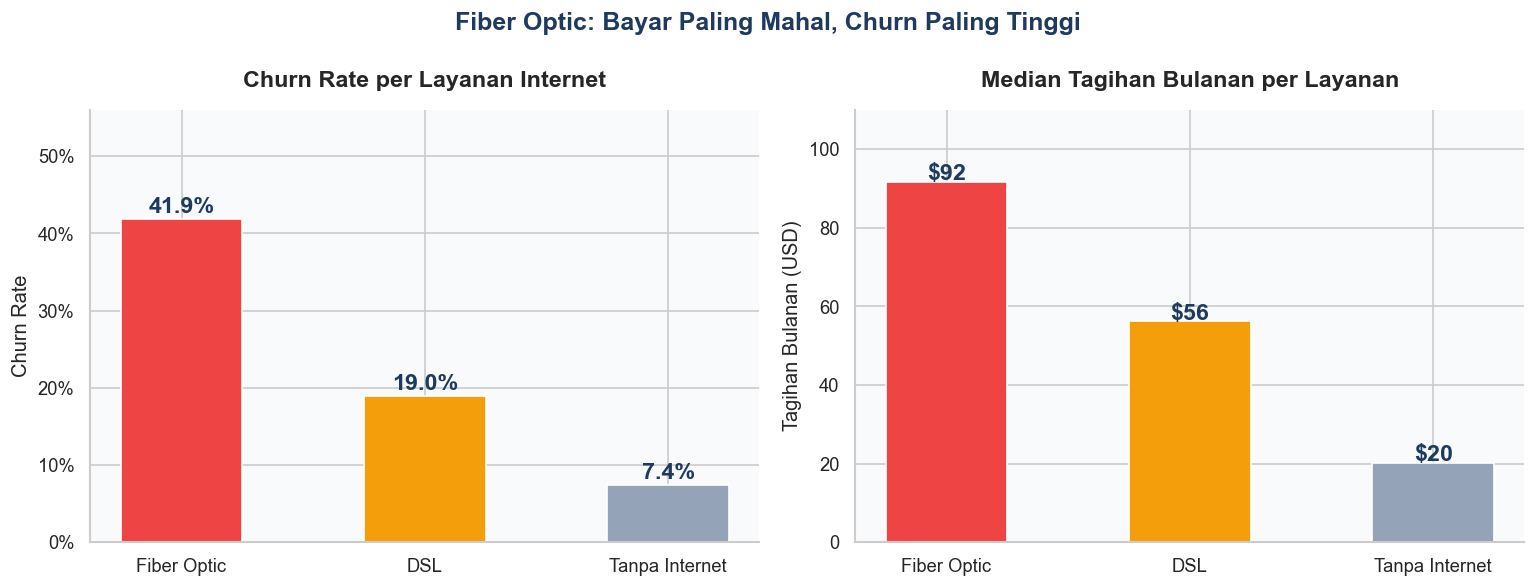

Fiber Optic: churn 41.9%, median tagihan $92
DSL        : churn 19.0%, median tagihan $56
Kesimpulan : Fiber Optic churn 22.9 poin lebih tinggi meski tagihannya $36 lebih mahal.


In [6]:
inet_rate = (df.groupby("InternetService")["Churn_Num"]
             .agg(["mean","count"])
             .rename(columns={"mean":"churn_rate","count":"total"})
             .reset_index()
             .sort_values("churn_rate", ascending=False))

inet_monthly = df.groupby("InternetService")["MonthlyCharges"].median().reset_index()
inet_monthly.columns = ["InternetService","MedianMonthly"]
inet_rate = inet_rate.merge(inet_monthly, on="InternetService")

label_inet = {"Fiber optic": "Fiber Optic", "DSL": "DSL", "No": "Tanpa Internet"}
inet_rate["Label"] = inet_rate["InternetService"].map(label_inet)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_inet = [RED if svc == "Fiber optic" else (GOLD if svc == "DSL" else GRAY)
               for svc in inet_rate["InternetService"]]

# Churn rate
bars1 = axes[0].bar(inet_rate["Label"], inet_rate["churn_rate"],
                    color=colors_inet, width=0.5, edgecolor="white")
for bar, rate in zip(bars1, inet_rate["churn_rate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f"{rate:.1%}", ha="center", fontsize=14, fontweight="bold", color=DARK)
axes[0].set_title("Churn Rate per Layanan Internet")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim(0, 0.56)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Median tagihan
bars2 = axes[1].bar(inet_rate["Label"], inet_rate["MedianMonthly"],
                    color=colors_inet, width=0.5, edgecolor="white")
for bar, val in zip(bars2, inet_rate["MedianMonthly"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"${val:.0f}", ha="center", fontsize=14, fontweight="bold", color=DARK)
axes[1].set_title("Median Tagihan Bulanan per Layanan")
axes[1].set_ylabel("Tagihan Bulanan (USD)")
axes[1].set_ylim(0, max(inet_rate["MedianMonthly"]) * 1.20)

plt.suptitle("Fiber Optic: Bayar Paling Mahal, Churn Paling Tinggi",
             fontsize=15, fontweight="bold", color=DARK)
plt.tight_layout()
plt.savefig("../reports/internet_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

fiber = inet_rate[inet_rate["InternetService"]=="Fiber optic"].iloc[0]
dsl   = inet_rate[inet_rate["InternetService"]=="DSL"].iloc[0]
print(f"Fiber Optic: churn {fiber['churn_rate']:.1%}, median tagihan ${fiber['MedianMonthly']:.0f}")
print(f"DSL        : churn {dsl['churn_rate']:.1%}, median tagihan ${dsl['MedianMonthly']:.0f}")
print(f"Kesimpulan : Fiber Optic churn {(fiber['churn_rate']-dsl['churn_rate'])*100:.1f} poin lebih tinggi meski tagihannya ${fiber['MedianMonthly']-dsl['MedianMonthly']:.0f} lebih mahal.")


## 7. Distribusi Variabel Numerik: Tagihan vs Status Churn

Tiga variabel numerik utama dalam dataset ini — lama berlangganan, tagihan bulanan, dan total tagihan sepanjang masa — semuanya menunjukkan pola yang berbeda antara pelanggan yang churn dan yang bertahan.

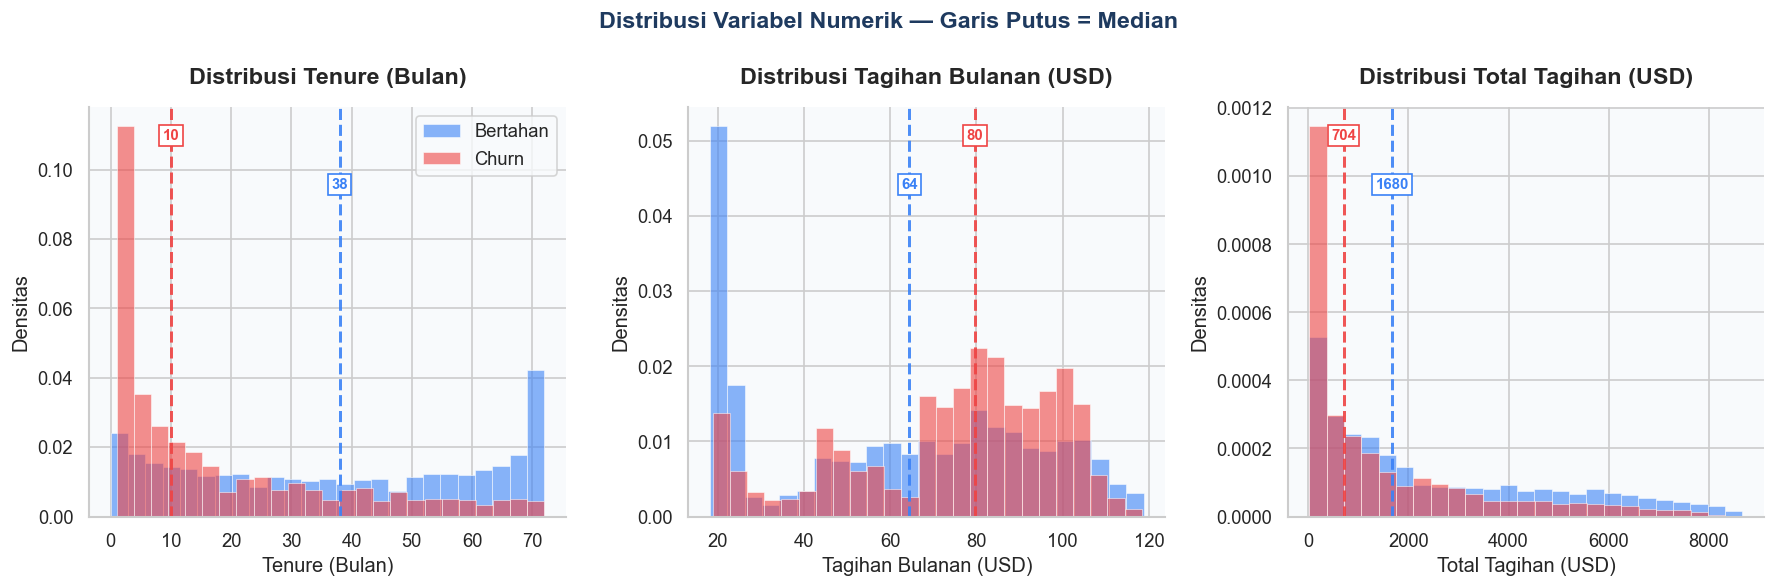

In [7]:
num_vars = [
    ("tenure",         "Tenure (Bulan)"),
    ("MonthlyCharges", "Tagihan Bulanan (USD)"),
    ("TotalCharges",   "Total Tagihan (USD)")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, num_vars):
    for status, color, name in [("No", BLUE, "Bertahan"), ("Yes", RED, "Churn")]:
        subset = df[df["Churn"]==status][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label=f"{name}", edgecolor="white", linewidth=0.5, density=True)
    
    med_c = df[df["Churn"]=="Yes"][col].median()
    med_s = df[df["Churn"]=="No"][col].median()

    ax.axvline(med_c, color=RED, linestyle="--", linewidth=1.8, alpha=0.9)
    ax.axvline(med_s, color=BLUE, linestyle="--", linewidth=1.8, alpha=0.9)

    ymax = ax.get_ylim()[1]
    ax.text(med_c, ymax*0.92, f"{med_c:.0f}", ha="center", fontsize=9,
            color=RED, fontweight="bold", bbox=dict(facecolor="white", edgecolor=RED, pad=2))
    ax.text(med_s, ymax*0.80, f"{med_s:.0f}", ha="center", fontsize=9,
            color=BLUE, fontweight="bold", bbox=dict(facecolor="white", edgecolor=BLUE, pad=2))

    ax.set_xlabel(label)
    ax.set_ylabel("Densitas")
    ax.set_title(f"Distribusi {label}")
    if ax == axes[0]:
        ax.legend(loc="upper right")

plt.suptitle("Distribusi Variabel Numerik — Garis Putus = Median",
             fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.savefig("../reports/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Peta Risiko: Tenure vs Tagihan Bulanan

Scatter plot ini menggabungkan dua temuan sebelumnya dalam satu gambar. Pojok kiri atas adalah zona paling berbahaya: tenure rendah (pelanggan baru) dengan tagihan tinggi (kemungkinan Fiber Optic). Kombinasi ini adalah profil risiko churn tertinggi yang harus menjadi prioritas intervensi.

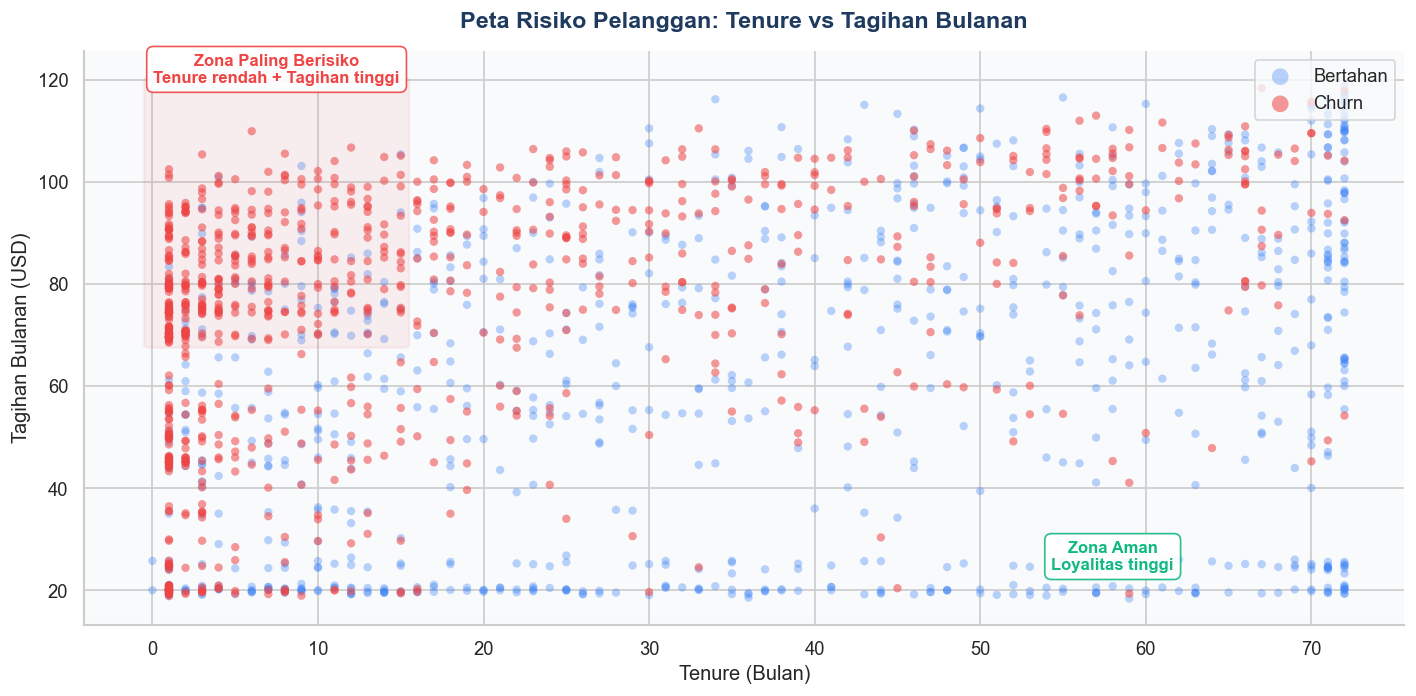

In [8]:
sample = df.groupby("Churn", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 900), random_state=42)
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

for status, color, name, alpha in [("No", BLUE, "Bertahan", 0.35), ("Yes", RED, "Churn", 0.55)]:
    subset = sample[sample["Churn"]==status]
    ax.scatter(subset["tenure"], subset["MonthlyCharges"],
               c=color, alpha=alpha, s=25, label=name, edgecolors="none")

# Zona bahaya
from matplotlib.patches import FancyBboxPatch
box = FancyBboxPatch((0, 68), 15, 52, linewidth=1.5,
                      edgecolor=RED, facecolor=RED, alpha=0.07,
                      boxstyle="round,pad=0.5")
ax.add_patch(box)
ax.text(7.5, 122, "Zona Paling Berisiko\nTenure rendah + Tagihan tinggi",
        ha="center", va="center", fontsize=10, fontweight="bold", color=RED,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=RED, alpha=0.9))

# Zona aman
ax.text(58, 24, "Zona Aman\nLoyalitas tinggi",
        ha="center", fontsize=10, fontweight="bold", color=GREEN,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GREEN, alpha=0.9))

ax.set_xlabel("Tenure (Bulan)", fontsize=12)
ax.set_ylabel("Tagihan Bulanan (USD)", fontsize=12)
ax.set_title("Peta Risiko Pelanggan: Tenure vs Tagihan Bulanan",
             fontsize=14, fontweight="bold", color=DARK)
ax.legend(loc="upper right", markerscale=2)
plt.tight_layout()
plt.savefig("../reports/risk_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Semakin Banyak Layanan = Semakin Setia

Pelanggan yang menggunakan lebih banyak layanan tambahan (Online Security, Tech Support, Streaming, dll.) terbukti jauh lebih sulit untuk berpindah. Semakin terintegrasi seorang pelanggan ke dalam ekosistem layanan, semakin besar biaya psikologis dan operasional untuk berpindah ke kompetitor.

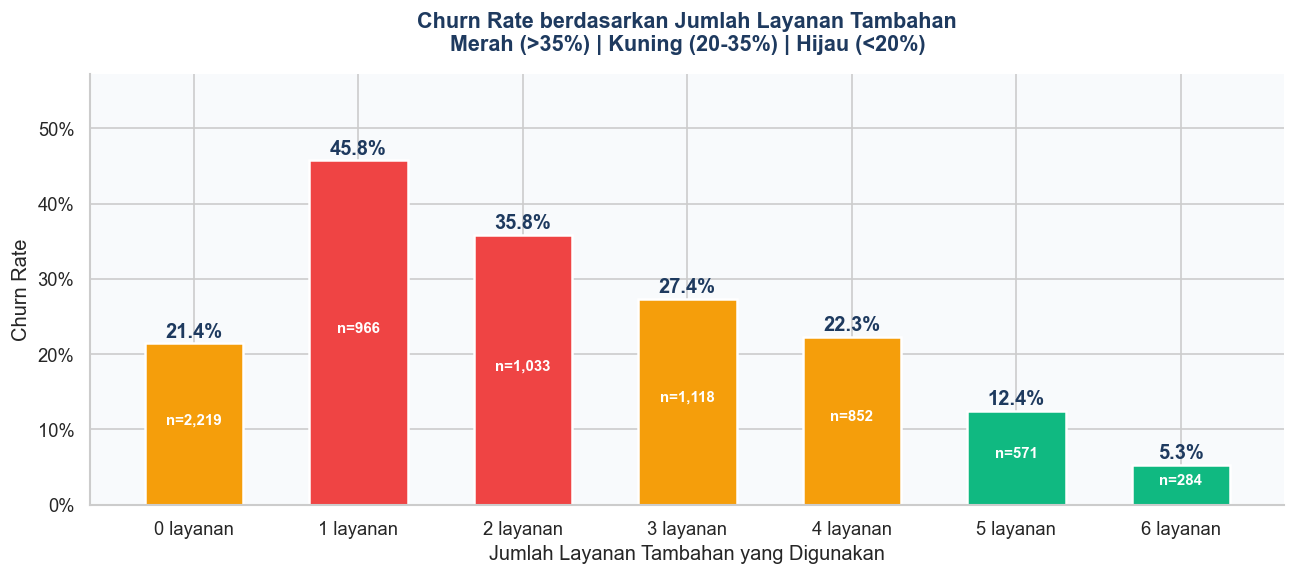

In [9]:
svc_cols = ["OnlineSecurity","OnlineBackup","DeviceProtection",
            "TechSupport","StreamingTV","StreamingMovies"]

df["ServiceCount"] = df[svc_cols].apply(lambda row: (row == "Yes").sum(), axis=1)

svc_stats = (df.groupby("ServiceCount")["Churn_Num"]
             .agg(["mean","count"])
             .rename(columns={"mean":"churn_rate","count":"total"})
             .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = [RED if r >= 0.35 else (GOLD if r >= 0.20 else GREEN)
              for r in svc_stats["churn_rate"]]

bars = ax.bar(svc_stats["ServiceCount"], svc_stats["churn_rate"],
              color=bar_colors, width=0.6, edgecolor="white", linewidth=1.5)

for bar, rate, total in zip(bars, svc_stats["churn_rate"], svc_stats["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{rate:.1%}", ha="center", fontsize=12, fontweight="bold", color=DARK)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f"n={total:,}", ha="center", fontsize=9, color="white", fontweight="bold")

ax.set_xlabel("Jumlah Layanan Tambahan yang Digunakan", fontsize=12)
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate berdasarkan Jumlah Layanan Tambahan\n"
             "Merah (>35%) | Kuning (20-35%) | Hijau (<20%)",
             fontsize=13, fontweight="bold", color=DARK)
ax.set_xticks(svc_stats["ServiceCount"])
ax.set_xticklabels([f"{n} layanan" for n in svc_stats["ServiceCount"]])
ax.set_ylim(0, svc_stats["churn_rate"].max() * 1.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.savefig("../reports/service_count_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Ringkasan Temuan EDA

Dari seluruh analisis eksplorasi di atas, empat temuan utama menjadi fondasi modeling dan rekomendasi bisnis:

**Temuan 1 — 12 Bulan Pertama adalah Jendela Kritis**

Median tenure churner hanya 10 bulan vs 38 bulan untuk non-churner. Selisih 28 bulan ini menunjukkan bahwa pelanggan yang berhasil melewati tahun pertama membangun kebiasaan dan switching cost psikologis yang jauh lebih tinggi. Program onboarding yang kuat di fase awal adalah investasi retensi yang paling efisien.

**Temuan 2 — Kontrak Bulanan: Risiko Tinggi, Solusi Jelas**

Churn rate kontrak bulanan mencapai 42,7% dibanding 2,8% pada kontrak dua tahun. Perbedaan 40 poin persentase ini adalah lever bisnis paling langsung yang tersedia: mendorong konversi ke kontrak tahunan dengan insentif yang tepat.

**Temuan 3 — Anomali Fiber Optic Perlu Diselidiki**

Layanan paling mahal justru memiliki churn rate tertinggi (41,9%). Ini bukan masalah harga, melainkan gap ekspektasi vs pengalaman aktual yang perlu diinvestigasi melalui audit kualitas layanan per wilayah.

**Temuan 4 — Ekosistem Layanan Melindungi dari Churn**

Electronic check (45,3% churn) vs auto-pay (di bawah 20%). Pelanggan dengan 4+ layanan tambahan memiliki churn rate di bawah 10%. Mendorong penggunaan lebih banyak layanan dan migrasi ke pembayaran otomatis adalah strategi retensi yang cost-effective dan terukur.

---
*Lanjutkan ke Notebook 02 untuk preprocessing dan persiapan data modeling.*